# The BBM equation, a solitary wave, periodic cubic splines and RK4

We solve the Benjamin-Bona-Mahony (BBM) equation

$$u_t - u_{xxt} + u_x + u\,u_x = 0, \qquad -80 < x < 80, \quad 0 < t \le T,$$

with periodic boundary conditions. It has the solitary wave solution

$$u(x, t) = 3(c - 1)\,\mathrm{sech}^2\left(\tfrac{1}{2}\sqrt{1 - 1/c}\,(x - c\,t)\right),$$

which travels to the right with speed $c$ without changing its shape. We take $c = 1.5$, so the wave has amplitude $1.5$.

On the periodic domain of length $L = 160$ the wave leaves on the right and comes back on the left. The exact solution is then the periodic extension of the solitary wave,

$$u(x, t) = \sum_{k} 3(c - 1)\,\mathrm{sech}^2\left(\tfrac{1}{2}\sqrt{1 - 1/c}\,(x - c\,t - k L)\right),$$

the sum of the wave and its copies shifted by multiples of $L$. The tails decay exponentially and are below $10^{-19}$ half a period from the crest, so the copies overlap only at rounding level and the sum is a solution to rounding. For any time it is enough to move the crest $c\,t$ back into the domain and add its two neighbors, so the run can be as long as we like.

Multiplying by a periodic test function $v$ and integrating the term $u_{xxt}$ by parts gives the weak form

$$\int u_t\, v \, dx + \int u_{xt}\, v' \, dx = -\int \left(u_x + u\,u_x\right) v \, dx,$$

for every test function $v$. In the spline space this is a system of ordinary differential equations $M\,c'(t) = f(c)$, where $M$ is the matrix of the left-hand side and $f$ the vector of the right-hand side.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx

Periodic cubic splines on 320 equal elements of $[-80, 80]$. The periodic condition is built into the space, so there is nothing else to impose.

In [2]:
grid = np.linspace(-80, 80, 1601)
V = fd.SplineSpace(grid, 3, bc="periodic")
u, v = fd.TrialFunction(V), fd.TestFunction(V)

The solution is a `Function` of `V`, here called `w`. It starts as the $L^2$ projection of the solitary wave at $t = 0$, and the time stepper updates it in place.

In [3]:
c = 1.5
amp, kappa = 3 * (c - 1), 0.5 * np.sqrt(1 - 1 / c)
a, b = grid[0], grid[-1]
L = b - a                                         # the period

def exact(x, t, cosh=np.cosh):
    """The periodic solitary wave at time t. x is an array (cosh=np.cosh) or fd.x (cosh=fd.cosh)."""
    s = (c * t - a) % L + a                       # the crest c t, moved back into [a, b)
    return sum(amp / cosh(kappa * (x - s - k * L))**2 for k in (-1, 0, 1))

w = fd.Function(V, "w")
w.project(exact(fd.x, 0.0, fd.cosh))
w0 = w.vector.copy()                              # the initial coefficients, kept for the plot

The two sides of the weak form. `M` is the bilinear form $\int (u v + u' v')\,dx$, and `f` the right-hand side, linear in $v$ and nonlinear in `w`.

BBM conserves the mass $I_1 = \int u\,dx$ and the energy $I_2 = \int (u^2 + u_x^2)\,dx$. These are forms with no test function, so they assemble to numbers.

In [4]:
M = fd.form((u * v + D(u) * D(v)) * dx)
f = fd.form(-(D(w) + w * D(w)) * v * dx)

I1 = fd.form(w * dx)
I2 = fd.form((w**2 + D(w)**2) * dx)
I1_0, I2_0 = I1.assemble(), I2.assemble()
print("I1 =", I1_0, "  I2 =", I2_0)

I1 = 10.392304845413248   I2 = 11.085125168442755


`fd.ERK` advances $M c' = f(c)$ by an explicit Runge-Kutta method, here the classical fourth-order method. $M$ is factored once, and each of the four stages is one assembly of `f` and one solve with $M$. Each call `rk.step(w)` advances `w` by one step $\Delta t = 0.05$, and `rk.t` is the current time.

In [5]:
dt, T = 0.05, 100.0
rk = fd.ERK(M, f, dt, "rk4", backend="fft")

for n in range(int(round(T / dt))):
    rk.step(w)
print("t =", rk.t)

t = 99.99999999999646


We compare with the exact solution at the final time $T$, using the maximum error sampled on 4001 points and the $L^2$ error integrated by quadrature on each element. RK4 conserves $I_1$, which is linear, to rounding, and $I_2$ up to a small error of the order of the time-stepping error.

max error: 8.752719654614438e-07
L2 error:  2.1412316372137088e-06
change in I1: 2.078337502098293e-13
change in I2: 5.054674527826819e-07


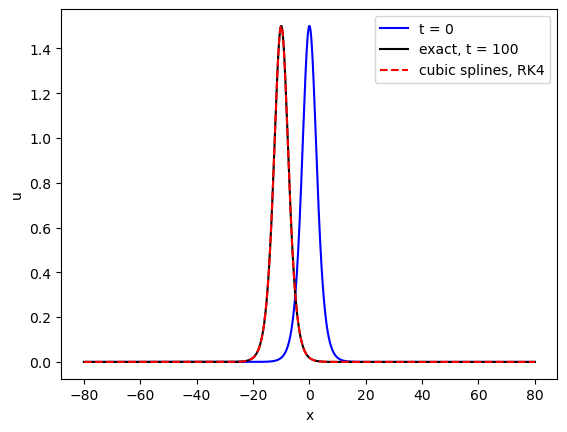

In [6]:
t = rk.t
xs = np.linspace(-80, 80, 4001)
uexact = exact(xs, t)
print("max error:", np.max(np.abs(w(xs) - uexact)))

uex = exact(fd.x, t, fd.cosh)                     # the exact solution at time t, as an expression in x
print("L2 error: ", np.sqrt(fd.form((w - uex)**2 * dx).assemble()))
print("change in I1:", abs(I1.assemble() - I1_0))
print("change in I2:", abs(I2.assemble() - I2_0))

u0 = fd.Function(V, w0)                           # the initial condition, from the saved coefficients
plt.plot(xs, u0(xs), "b-", label="t = 0")
plt.plot(xs, uexact, "k-", label=f"exact, t = {t:g}")
plt.plot(xs, w(xs), "r--", label="cubic splines, RK4")
plt.xlabel("x"); plt.ylabel("u"); plt.legend()
plt.show()

**A check with an implicit Gauss method.** The semi-discrete system conserves $I_2$ exactly, because $I_2 = c^T M c$ is a quadratic invariant of $M c' = f(c)$. The Gauss-Legendre Runge-Kutta methods conserve every quadratic invariant, so with `fd.IRK` and `"gauss"` the energy is conserved to rounding at every step. `fd.IRK` takes `M` and `f` exactly as `fd.ERK` does, and solves the stage equations by Newton's method with the exact Jacobian, taken symbolically from `f`. Here two stages, of order 4.

In [7]:
wg = fd.Function(V, "wg")
wg.project(exact(fd.x, 0.0, fd.cosh))
fg = fd.form(-(D(wg) + wg * D(wg)) * v * dx)     # the same right-hand side, in wg
I2g = fd.form((wg**2 + D(wg)**2) * dx)

irk = fd.IRK(M, fg, dt, "gauss", 2)
for n in range(int(round(T / dt))):
    info = irk.step(wg)
print(info)

print("max error:   ", np.max(np.abs(wg(xs) - uexact)))
print("change in I2:", abs(I2g.assemble() - I2_0))
print("max |RK4 - Gauss|:", np.max(np.abs(w(xs) - wg(xs))))

NewtonInfo(converged in 2 iterations, ||R|| 3.09e-02 -> 2.90e-15, converged on the step: the error left is below xtol, ||F|| is at its round-off floor)
max error:    1.5866192804026014e-07
change in I2: 3.552713678800501e-13
max |RK4 - Gauss|: 7.166732797214692e-07
